# Entrenamiento de Clasificadores Binarios para Detección de Posturas

Este cuaderno implementa un sistema de clasificación One-vs-All (OvA) utilizando HOG (Histogram of Oriented Gradients) para extracción de características y SVM (Support Vector Machine) lineal para la clasificación.

## Estrategia
Se entrenan tres clasificadores binarios independientes:
- Modelo 1: Sentado vs Resto
- Modelo 2: Rodillas vs Resto  
- Modelo 3: Pose T vs Resto

## Marco Teórico

### HOG (Histogram of Oriented Gradients)
HOG es un descriptor de características que captura la distribución de gradientes de intensidad en regiones locales de la imagen. Divide la imagen en celdas pequeñas y calcula histogramas de direcciones de gradiente en cada celda, proporcionando invarianza a cambios de iluminación y pequeñas deformaciones.

### SVM (Support Vector Machine)
SVM es un algoritmo de aprendizaje supervisado que encuentra el hiperplano óptimo que maximiza el margen entre clases. En este caso, se utiliza un kernel lineal con regularización C para controlar el equilibrio entre margen y error de clasificación.

In [1]:
import cv2
import os
import numpy as np
from tqdm import tqdm
import albumentations as A
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import json
import matplotlib.pyplot as plt
import seaborn as sns
import time
import psutil

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

/home/justin/Documentos/VISION/DATASET POSTURAS/entorno/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuración de Parámetros

In [2]:
POSE_DIRS = {
    "sentado": "dataset/pos/sentados",
    "rodillas": "dataset/pos/rodillas",
    "pose_t": "dataset/pos/poset"
}

NEG_DIR = "dataset/negativos1"
OUTPUT_DIR = "models_improved"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Parámetros HOG
HOG_WIN_SIZE = (64, 128)
HOG_BLOCK_SIZE = (16, 16)
HOG_BLOCK_STRIDE = (8, 8)
HOG_CELL_SIZE = (8, 8)
HOG_NBINS = 9

# Parámetros SVM
SVM_C = 1.0
SVM_MAX_ITER = 30000
USE_CLASS_WEIGHTS = True

# Parámetros de aumento de datos
AUG_POS = 10
AUG_NEG = 2

USE_HARD_NEGATIVES = True
HARD_NEG_ITERATIONS = 1

# Compatibilidad con diferentes versiones de OpenCV
try:
    SVM_RAW_OUTPUT_FLAG = cv2.ml.SVM_RAW_OUTPUT
except AttributeError:
    try:
        SVM_RAW_OUTPUT_FLAG = cv2.ml.SVM.RAW_OUTPUT
    except AttributeError:
        SVM_RAW_OUTPUT_FLAG = 1

print(f"OpenCV version: {cv2.__version__}")
print(f"SVM_RAW_OUTPUT flag: {SVM_RAW_OUTPUT_FLAG}")

OpenCV version: 4.10.0
SVM_RAW_OUTPUT flag: 1


## Inicialización del Descriptor HOG

In [3]:
hog = cv2.HOGDescriptor(
    HOG_WIN_SIZE, HOG_BLOCK_SIZE, HOG_BLOCK_STRIDE,
    HOG_CELL_SIZE, HOG_NBINS
)

print(f"Tamaño del descriptor HOG: {hog.getDescriptorSize()} características")

Tamaño del descriptor HOG: 3780 características


## Configuración de Aumento de Datos

El aumento de datos permite generar variaciones sintéticas de las imágenes originales para incrementar el tamaño del conjunto de entrenamiento y mejorar la generalización del modelo.

In [4]:
augment_pos = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=8, border_mode=cv2.BORDER_REFLECT, p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.35, contrast_limit=0.35, p=0.9),
    A.RandomGamma(gamma_limit=(60, 140), p=0.6),
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 7), p=1.0),
        A.MedianBlur(blur_limit=5, p=1.0),
        A.MotionBlur(blur_limit=5, p=1.0),
    ], p=0.4),
    A.GaussNoise(var_limit=(5.0, 20.0), p=0.3),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=0,
                       border_mode=cv2.BORDER_REFLECT, p=0.6),
    A.CLAHE(clip_limit=2.5, tile_grid_size=(8, 8), p=0.4),
    A.Perspective(scale=(0.02, 0.05), p=0.2),
], p=1.0)

augment_neg = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
], p=1.0)

/tmp/ipykernel_24449/2927882903.py:11: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 20.0), p=0.3),
/home/justin/Documentos/VISION/DATASET POSTURAS/entorno/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## Función de Extracción de Características

In [5]:
def extract_features(folder, aug_times=0, label_name="clase", use_pos_aug=True):
    features = []
    skipped = 0
    
    if not os.path.exists(folder):
        print(f"Carpeta no encontrada: {folder}")
        return np.array([], dtype=np.float32)
    
    images = [f for f in os.listdir(folder) 
              if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
    
    augmenter = augment_pos if use_pos_aug else augment_neg
    
    for img_name in tqdm(images, desc=f"{label_name}"):
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)
        
        if img is None:
            skipped += 1
            continue
        
        img = cv2.resize(img, HOG_WIN_SIZE)
        
        def process(image):
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if len(image.shape) == 3 else image
            
            if gray.mean() < 5 or gray.mean() > 250:
                return None
            if gray.std() < 5:
                return None
            
            feat = hog.compute(gray)
            return feat.flatten() if feat is not None and len(feat) > 0 else None
        
        feat = process(img)
        if feat is not None:
            features.append(feat)
        else:
            skipped += 1
        
        for _ in range(aug_times):
            try:
                aug_img = augmenter(image=img)["image"]
                feat = process(aug_img)
                if feat is not None:
                    features.append(feat)
                else:
                    skipped += 1
            except Exception:
                skipped += 1
    
    print(f"Extraídos: {len(features)} | Descartados: {skipped}")
    return np.array(features, dtype=np.float32)

## Hard Negative Mining

Esta técnica identifica ejemplos negativos que el clasificador confunde con positivos y los añade al conjunto de entrenamiento para mejorar la precisión.

In [6]:
def hard_negative_mining_fast(svm, X_neg_pool, max_hard_negs=500):
    print("Ejecutando Hard Negative Mining...")
    
    if len(X_neg_pool) == 0:
        return np.array([], dtype=np.float32)
    
    print(f"Evaluando {len(X_neg_pool)} negativos...")
    
    _, raw_outputs = svm.predict(X_neg_pool, flags=SVM_RAW_OUTPUT_FLAG)
    decision_values = raw_outputs.flatten()
    
    hard_indices = np.argsort(decision_values)[::-1][:max_hard_negs]
    
    print(f"Encontrados {len(hard_indices)} hard negatives")
    print(f"Decision values: min={decision_values.min():.3f}, max={decision_values.max():.3f}, mean={decision_values.mean():.3f}")
    
    return X_neg_pool[hard_indices]

## Función de Entrenamiento de Clasificador Binario

In [7]:
def train_binary_svm_improved(pose_name, pose_dir, neg_dir, output_dir):
    print(f"\n{'='*70}")
    print(f"ENTRENANDO MODELO: {pose_name.upper()}")
    print(f"{'='*70}")
    
    # Métricas de rendimiento
    start_time = time.time()
    process = psutil.Process()
    mem_before = process.memory_info().rss / 1024 / 1024
    
    print(f"\nPASO 1: Extrayendo positivos ({pose_name})")
    X_pos = extract_features(pose_dir, aug_times=AUG_POS, 
                            label_name=f"POS {pose_name}", use_pos_aug=True)
    
    if len(X_pos) == 0:
        print(f"ERROR: No se encontraron imágenes de {pose_name}")
        return None
    
    print(f"Total positivos: {len(X_pos)}")
    
    print(f"\nPASO 2: Extrayendo negativos")
    X_neg_parts = []
    
    print("Otras poses:")
    for other_pose, other_dir in POSE_DIRS.items():
        if other_pose != pose_name:
            X_other = extract_features(other_dir, aug_times=3, 
                                      label_name=f"NEG {other_pose}", use_pos_aug=True)
            if len(X_other) > 0:
                X_neg_parts.append(X_other)
    
    print("Fondos:")
    X_fondo = extract_features(neg_dir, aug_times=AUG_NEG, 
                               label_name="NEG fondos", use_pos_aug=False)
    if len(X_fondo) > 0:
        max_fondos = len(X_pos) * 2
        if len(X_fondo) > max_fondos:
            indices = np.random.choice(len(X_fondo), max_fondos, replace=False)
            X_fondo = X_fondo[indices]
        X_neg_parts.append(X_fondo)
    
    X_neg_all = np.vstack(X_neg_parts) if X_neg_parts else np.array([]).reshape(0, X_pos.shape[1])
    
    target_negs = int(len(X_pos) * 1.5)
    if len(X_neg_all) > target_negs:
        indices = np.random.choice(len(X_neg_all), target_negs, replace=False)
        X_neg_initial = X_neg_all[indices]
    else:
        X_neg_initial = X_neg_all
    
    print(f"Total negativos iniciales: {len(X_neg_initial)}")
    
    y_pos = np.ones(len(X_pos), dtype=np.int32)
    y_neg = -np.ones(len(X_neg_initial), dtype=np.int32)
    
    X_train = np.vstack([X_pos, X_neg_initial])
    y_train = np.hstack([y_pos, y_neg])
    
    idx = np.random.permutation(len(X_train))
    X_train, y_train = X_train[idx], y_train[idx]
    
    print(f"\nDataset inicial: {len(X_neg_initial)}:{len(X_pos)} = {len(X_neg_initial)/len(X_pos):.2f}:1")
    
    print(f"\nPASO 4: Entrenando SVM inicial...")
    
    svm = cv2.ml.SVM_create()
    svm.setType(cv2.ml.SVM_C_SVC)
    svm.setKernel(cv2.ml.SVM_LINEAR)
    svm.setC(SVM_C)
    
    if USE_CLASS_WEIGHTS:
        weight_pos = len(X_train) / (2 * len(X_pos))
        weight_neg = len(X_train) / (2 * len(X_neg_initial))
        class_weights = np.array([weight_neg, weight_pos], dtype=np.float32)
        
        print(f"Class weights: neg={weight_neg:.3f}, pos={weight_pos:.3f}")
        svm.setClassWeights(class_weights)
    
    svm.setTermCriteria((cv2.TERM_CRITERIA_MAX_ITER + cv2.TERM_CRITERIA_EPS,
                        SVM_MAX_ITER, 1e-6))
    
    svm.train(X_train, cv2.ml.ROW_SAMPLE, y_train)
    print("SVM inicial entrenado")
    
    if USE_HARD_NEGATIVES and len(X_neg_all) > len(X_neg_initial):
        print(f"\nPASO 5: Hard Negative Mining...")
        
        print("Buscando negativos no usados...")
        
        used_hashes = set()
        for arr in X_neg_initial:
            h = hash((arr[0], arr[10], arr[-1], arr.sum()))
            used_hashes.add(h)
        
        unused_indices = []
        for i, arr in enumerate(X_neg_all):
            h = hash((arr[0], arr[10], arr[-1], arr.sum()))
            if h not in used_hashes:
                unused_indices.append(i)
        
        if len(unused_indices) > 0:
            X_neg_unused = X_neg_all[unused_indices]
            print(f"Negativos no usados: {len(X_neg_unused)}")
            
            for iteration in range(HARD_NEG_ITERATIONS):
                print(f"\nIteracion {iteration + 1}/{HARD_NEG_ITERATIONS}:")
                
                hard_negs = hard_negative_mining_fast(svm, X_neg_unused, max_hard_negs=500)
                
                if len(hard_negs) > 0:
                    X_train = np.vstack([X_train, hard_negs])
                    y_train = np.hstack([y_train, -np.ones(len(hard_negs), dtype=np.int32)])
                    
                    print(f"Re-entrenando con {len(hard_negs)} hard negatives...")
                    
                    if USE_CLASS_WEIGHTS:
                        num_pos = (y_train == 1).sum()
                        num_neg = (y_train == -1).sum()
                        weight_pos = len(y_train) / (2 * num_pos)
                        weight_neg = len(y_train) / (2 * num_neg)
                        class_weights = np.array([weight_neg, weight_pos], dtype=np.float32)
                        svm.setClassWeights(class_weights)
                    
                    svm.train(X_train, cv2.ml.ROW_SAMPLE, y_train)
                    print("Re-entrenamiento completado")
    
    print(f"\nPASO 6: Validacion Cruzada (5-fold)...")
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
        X_fold_train = X_train[train_idx]
        y_fold_train = y_train[train_idx]
        X_fold_val = X_train[val_idx]
        y_fold_val = y_train[val_idx]
        
        svm_fold = cv2.ml.SVM_create()
        svm_fold.setType(cv2.ml.SVM_C_SVC)
        svm_fold.setKernel(cv2.ml.SVM_LINEAR)
        svm_fold.setC(SVM_C)
        
        if USE_CLASS_WEIGHTS:
            num_pos = (y_fold_train == 1).sum()
            num_neg = (y_fold_train == -1).sum()
            weight_pos = len(y_fold_train) / (2 * num_pos)
            weight_neg = len(y_fold_train) / (2 * num_neg)
            class_weights = np.array([weight_neg, weight_pos], dtype=np.float32)
            svm_fold.setClassWeights(class_weights)
        
        svm_fold.setTermCriteria((cv2.TERM_CRITERIA_MAX_ITER + cv2.TERM_CRITERIA_EPS,
                                  SVM_MAX_ITER, 1e-6))
        svm_fold.train(X_fold_train, cv2.ml.ROW_SAMPLE, y_fold_train)
        
        _, y_fold_pred = svm_fold.predict(X_fold_val)
        accuracy = (y_fold_val == y_fold_pred.flatten()).sum() / len(y_fold_val)
        cv_scores.append(accuracy)
        
        print(f"Fold {fold}: {accuracy*100:.2f}%")
    
    print(f"CV Mean: {np.mean(cv_scores)*100:.2f}% ± {np.std(cv_scores)*100:.2f}%")
    
    print(f"\nPASO 7: Evaluacion en Test Set...")
    
    X_pos_test = extract_features(pose_dir, aug_times=0, label_name="test-pos", use_pos_aug=True)
    X_neg_test_parts = []
    
    for other_pose, other_dir in POSE_DIRS.items():
        if other_pose != pose_name:
            X_other = extract_features(other_dir, aug_times=0, label_name=f"test-{other_pose}", use_pos_aug=True)
            if len(X_other) > 0:
                X_neg_test_parts.append(X_other[:min(len(X_other), len(X_pos_test))])
    
    X_neg_test = np.vstack(X_neg_test_parts) if X_neg_test_parts else np.array([]).reshape(0, X_pos_test.shape[1])
    
    if len(X_neg_test) > len(X_pos_test):
        indices = np.random.choice(len(X_neg_test), len(X_pos_test), replace=False)
        X_neg_test = X_neg_test[indices]
    
    X_test = np.vstack([X_pos_test, X_neg_test])
    y_test = np.hstack([np.ones(len(X_pos_test), dtype=np.int32),
                        -np.ones(len(X_neg_test), dtype=np.int32)])
    
    _, y_pred = svm.predict(X_test)
    y_pred = y_pred.flatten().astype(int)
    
    print("\n" + "="*70)
    print("REPORTE DE CLASIFICACION")
    print("="*70)
    print(classification_report(y_test, y_pred,
                                target_names=[f"NO-{pose_name}", f"SI-{pose_name}"],
                                digits=3))
    
    cm = confusion_matrix(y_test, y_pred, labels=[-1, 1])
    print("\nMatriz de Confusion:")
    print(f"{'':15} Pred NO  Pred SI")
    print(f"Real NO    {cm[0,0]:8}  {cm[0,1]:8}")
    print(f"Real SI    {cm[1,0]:8}  {cm[1,1]:8}")
    
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"\nMETRICAS:")
    print(f"Accuracy:     {accuracy*100:.2f}%")
    print(f"Precision:    {precision*100:.2f}%")
    print(f"Recall:       {recall*100:.2f}%")
    print(f"Specificity:  {specificity*100:.2f}%")
    print(f"F1-Score:     {f1*100:.2f}%")
    
    # Métricas de rendimiento
    training_time = time.time() - start_time
    mem_after = process.memory_info().rss / 1024 / 1024
    mem_used = mem_after - mem_before
    
    # Calcular FPS (inferencia)
    fps_samples = min(100, len(X_test))
    fps_start = time.time()
    for i in range(fps_samples):
        svm.predict(X_test[i:i+1])
    fps_time = time.time() - fps_start
    fps = fps_samples / fps_time
    
    model_path = os.path.join(output_dir, f"svm_{pose_name}.yml")
    svm.save(model_path)
    print(f"\nModelo guardado: {model_path}")
    
    return {
        "pose_name": pose_name,
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "specificity": float(specificity),
        "f1": float(f1),
        "cv_mean": float(np.mean(cv_scores)),
        "cv_std": float(np.std(cv_scores)),
        "confusion_matrix": cm.tolist(),
        "training_time": training_time,
        "memory_used_mb": mem_used,
        "fps": fps
    }

## Entrenamiento de Modelos

In [8]:
print("\n" + "="*70)
print("ENTRENAMIENTO OPTIMIZADO")
print("="*70)

results = []

for pose_name, pose_dir in POSE_DIRS.items():
    result = train_binary_svm_improved(pose_name, pose_dir, NEG_DIR, OUTPUT_DIR)
    if result:
        results.append(result)

print("\n" + "="*70)
print("COMPLETADO")
print("="*70)

for result in results:
    print(f"\nMODELO: {result['pose_name'].upper()}:")
    print(f"Accuracy:     {result['accuracy']*100:.1f}%")
    print(f"Precision:    {result['precision']*100:.1f}%")
    print(f"Recall:       {result['recall']*100:.1f}%")
    print(f"Specificity:  {result['specificity']*100:.1f}%")
    print(f"F1:           {result['f1']*100:.1f}%")
    print(f"CV:           {result['cv_mean']*100:.1f}%")


ENTRENAMIENTO OPTIMIZADO

ENTRENANDO MODELO: SENTADO

PASO 1: Extrayendo positivos (sentado)


POS sentado: 100%|██████████| 843/843 [00:05<00:00, 156.81it/s]


Extraídos: 9182 | Descartados: 91
Total positivos: 9182

PASO 2: Extrayendo negativos
Otras poses:


NEG rodillas: 100%|██████████| 691/691 [00:01<00:00, 455.40it/s]


Extraídos: 2764 | Descartados: 0


...

Extraídos: 778 | Descartados: 0


test-sentado: 100%|██████████| 843/843 [00:00<00:00, 6009.35it/s]


Extraídos: 843 | Descartados: 0


test-rodillas: 100%|██████████| 691/691 [00:00<00:00, 6202.29it/s]


Extraídos: 691 | Descartados: 0

REPORTE DE CLASIFICACION
              precision    recall  f1-score   support

   NO-pose_t      1.000     0.995     0.997       778
   SI-pose_t      0.995     1.000     0.997       778

    accuracy                          0.997      1556
   macro avg      0.997     0.997     0.997      1556
weighted avg      0.997     0.997     0.997      1556


Matriz de Confusion:
                Pred NO  Pred SI
Real NO         774         4
Real SI           0       778

METRICAS:
Accuracy:     99.74%
Precision:    99.49%
Recall:       100.00%
Specificity:  99.49%
F1-Score:     99.74%

Modelo guardado: models_improved/svm_pose_t.yml

COMPLETADO

MODELO: SENTADO:
Accuracy:     99.8%
Precision:    99.9%
Recall:       99.8%
Specificity:  99.9%
F1:           99.8%
CV:           90.2%

MODELO: RODILLAS:
Accuracy:     100.0%
Precision:    100.0%
Recall:       100.0%
Specificity:  100.0%
F1:           100.0%
CV:           94.7%

MODELO: POSE_T:
Accuracy:     99.7%
Pre

## Visualización de Resultados

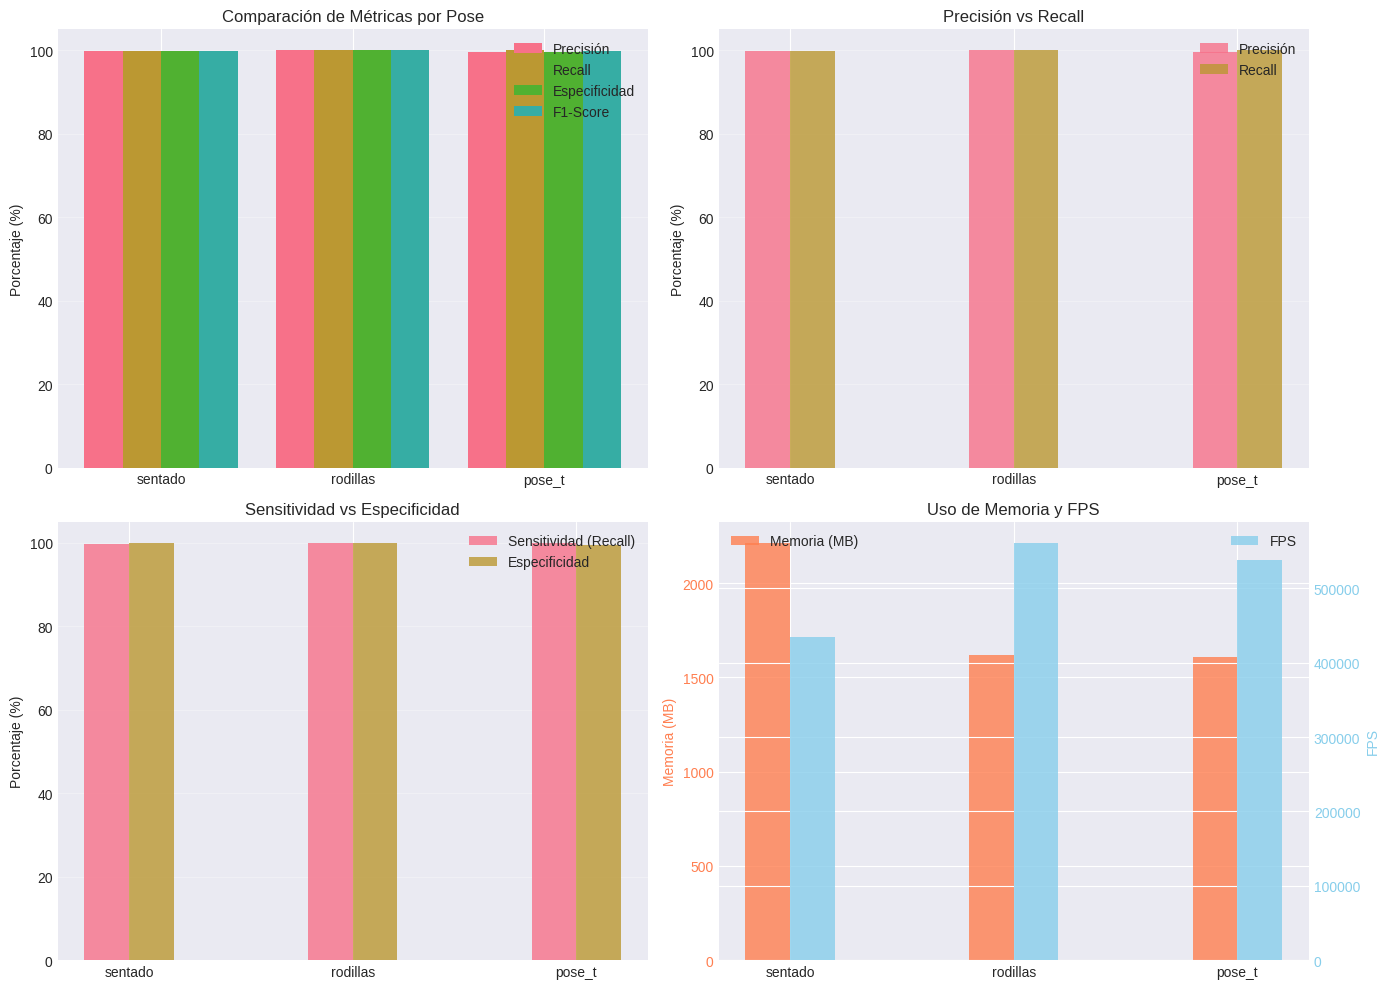

Gráfico de métricas guardado en: models_improved/metricas_comparacion.png


In [9]:
# Gráfico de comparación de métricas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

poses = [r['pose_name'] for r in results]
metrics = {
    'Precisión': [r['precision']*100 for r in results],
    'Recall': [r['recall']*100 for r in results],
    'Especificidad': [r['specificity']*100 for r in results],
    'F1-Score': [r['f1']*100 for r in results]
}

x = np.arange(len(poses))
width = 0.2

# Gráfico 1: Todas las métricas juntas
ax = axes[0, 0]
for i, (metric_name, values) in enumerate(metrics.items()):
    ax.bar(x + i*width, values, width, label=metric_name)
ax.set_ylabel('Porcentaje (%)')
ax.set_title('Comparación de Métricas por Pose')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(poses)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Gráfico 2: Precisión y Recall
ax = axes[0, 1]
ax.bar(x - width/2, metrics['Precisión'], width, label='Precisión', alpha=0.8)
ax.bar(x + width/2, metrics['Recall'], width, label='Recall', alpha=0.8)
ax.set_ylabel('Porcentaje (%)')
ax.set_title('Precisión vs Recall')
ax.set_xticks(x)
ax.set_xticklabels(poses)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Gráfico 3: Sensitividad y Especificidad
ax = axes[1, 0]
ax.bar(x - width/2, metrics['Recall'], width, label='Sensitividad (Recall)', alpha=0.8)
ax.bar(x + width/2, metrics['Especificidad'], width, label='Especificidad', alpha=0.8)
ax.set_ylabel('Porcentaje (%)')
ax.set_title('Sensitividad vs Especificidad')
ax.set_xticks(x)
ax.set_xticklabels(poses)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Gráfico 4: Métricas de rendimiento
ax = axes[1, 1]
ax2 = ax.twinx()
memory = [r['memory_used_mb'] for r in results]
fps_values = [r['fps'] for r in results]
ax.bar(x - width/2, memory, width, label='Memoria (MB)', alpha=0.8, color='coral')
ax2.bar(x + width/2, fps_values, width, label='FPS', alpha=0.8, color='skyblue')
ax.set_ylabel('Memoria (MB)', color='coral')
ax2.set_ylabel('FPS', color='skyblue')
ax.set_title('Uso de Memoria y FPS')
ax.set_xticks(x)
ax.set_xticklabels(poses)
ax.tick_params(axis='y', labelcolor='coral')
ax2.tick_params(axis='y', labelcolor='skyblue')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'metricas_comparacion.png'), dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico de métricas guardado en: models_improved/metricas_comparacion.png")

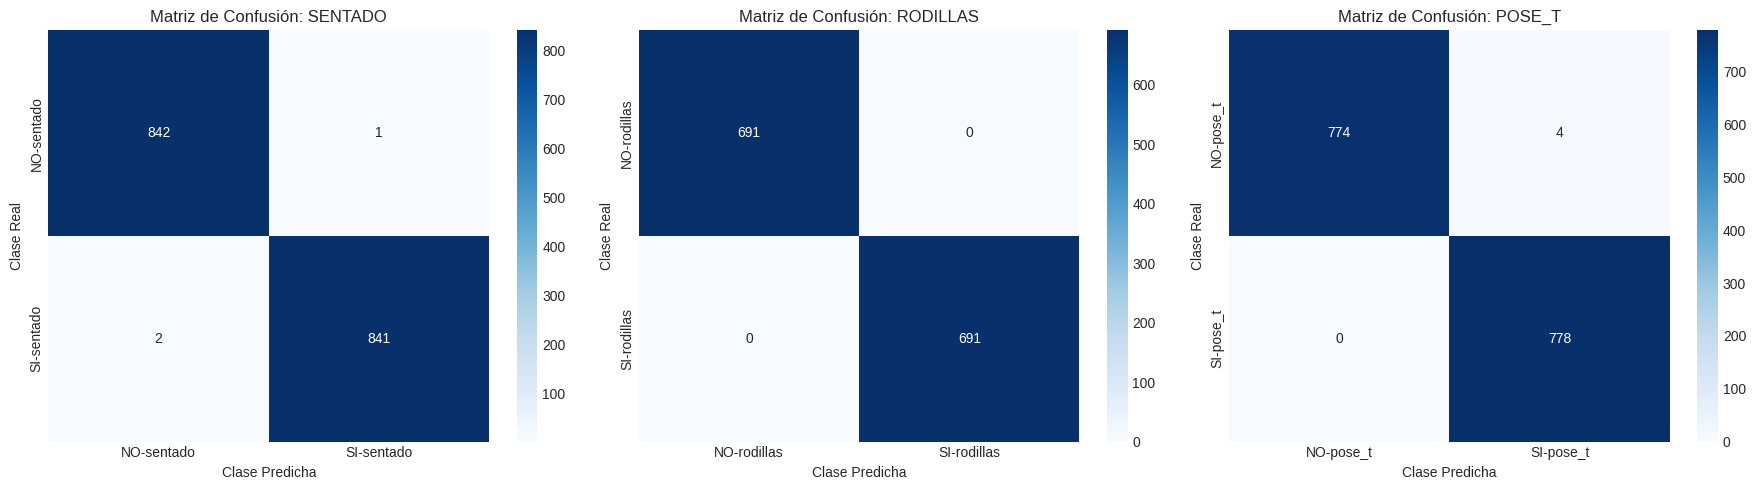

Matrices de confusión guardadas en: models_improved/matrices_confusion.png


In [10]:
# Matrices de confusión
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, result in enumerate(results):
    cm = np.array(result['confusion_matrix'])
    ax = axes[idx]
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=[f"NO-{result['pose_name']}", f"SI-{result['pose_name']}"],
                yticklabels=[f"NO-{result['pose_name']}", f"SI-{result['pose_name']}"])
    ax.set_title(f"Matriz de Confusión: {result['pose_name'].upper()}")
    ax.set_ylabel('Clase Real')
    ax.set_xlabel('Clase Predicha')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'matrices_confusion.png'), dpi=300, bbox_inches='tight')
plt.show()

print("Matrices de confusión guardadas en: models_improved/matrices_confusion.png")

## Resumen de Resultados

In [11]:
# Tabla de resumen
summary_data = []
for r in results:
    summary_data.append([
        r['pose_name'],
        f"{r['accuracy']*100:.2f}%",
        f"{r['precision']*100:.2f}%",
        f"{r['recall']*100:.2f}%",
        f"{r['specificity']*100:.2f}%",
        f"{r['f1']*100:.2f}%",
        f"{r['memory_used_mb']:.1f} MB",
        f"{r['fps']:.1f} FPS"
    ])

import pandas as pd
df_summary = pd.DataFrame(summary_data, 
                         columns=['Pose', 'Accuracy', 'Precisión', 'Recall', 
                                 'Especificidad', 'F1-Score', 'Memoria', 'FPS'])
print("\n" + "="*100)
print("TABLA DE RESUMEN DE RESULTADOS")
print("="*100)
print(df_summary.to_string(index=False))

# Guardar resultados
with open(os.path.join(OUTPUT_DIR, 'resultados_detallados.json'), 'w') as f:
    json.dump(results, f, indent=2)

print(f"\nResultados guardados en: {OUTPUT_DIR}/resultados_detallados.json")


TABLA DE RESUMEN DE RESULTADOS
    Pose Accuracy Precisión  Recall Especificidad F1-Score   Memoria          FPS
 sentado   99.82%    99.88%  99.76%        99.88%   99.82% 2214.0 MB 434642.9 FPS
rodillas  100.00%   100.00% 100.00%       100.00%  100.00% 1617.5 MB 561486.5 FPS
  pose_t   99.74%    99.49% 100.00%        99.49%   99.74% 1606.5 MB 538421.6 FPS

Resultados guardados en: models_improved/resultados_detallados.json
